# Replicate variation — how far apart are CTRPv2's repeated measurements?

Some (cell line, drug) combinations were screened by CTRPv2 **more than once**, in separate
experiments. `scripts/preprocessing/ctrp_to_h5ad.py::_build_drug_table` averages those repeats into
the single value that becomes the training target, and keeps no record that the averaging happened.

This notebook puts the two measurements of each repeated pair side by side and reports how far apart
they are. That is all it does.

**Scope:** the cell lines that overlap SCP542, i.e. exactly what trains — not all 1,107 lines CTRPv2
screened. **Score:** normalized AUC, `area_under_curve / conc_pts_fit`, the current target
(`layout.DEFAULT_CTRP_SCORE = "auc"`, decided 27.07.2026).

**Read-only.** It touches the shipped CTRPv2 files only, never the processed h5ad, so nothing here
depends on any decision the pipeline review may still change.

*Written 10.08.2026 for review item 2 (harmonization). The decision it informed — **keep averaging** —
is recorded in [Step 01](../../docs/steps/01-datasets-and-harmonization.md).*

## 1. The repeated pairs

The pipeline's own loader is imported rather than re-implemented, so the cell-line name matching here
is exactly the pipeline's — including the `H292` alias added 10.08.2026. `_load_ctrp_long` returns one
row per **(experiment, compound)**; a (cell line, drug) pair appears more than once precisely when it
was screened in more than one experiment.

In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.preprocessing.ctrp_to_h5ad import _load_ctrp_long, _normalize_cell_line
from scripts.preprocessing.layout import PipelinePaths

paths = PipelinePaths.build(None)          # DEFAULT_DATA_ROOT, hvg5000, score='auc'
ctrp = _load_ctrp_long(paths.ctrp_dir, paths.score)

# SCP542's cell lines, normalized the way the pipeline normalizes them.
meta = pd.read_csv(paths.meta_file, sep='\t', low_memory=False)
meta = meta[meta['NAME'] != 'TYPE']        # the second header row declaring column types
scp_lines = set(_normalize_cell_line(meta['Cell_line'].astype(str).str.split('_').str[0]))

ov = ctrp[ctrp['ccl_name_norm'].isin(scp_lines)]
n_exp = ov.groupby(['ccl_name_norm', 'cpd_name_norm'])['experiment_id'].transform('nunique')
rep = ov[n_exp > 1]

print(f"overlapping cell lines      : {ov['ccl_name_norm'].nunique()}")
print(f"(cell line, drug) pairs     : {len(ov.groupby(['ccl_name_norm', 'cpd_name_norm']))}")
print(f"  screened more than once   : {len(rep.groupby(['ccl_name_norm', 'cpd_name_norm']))}")
print(f"  cell lines involved       : {rep['ccl_name_norm'].nunique()}")
print(f"  drugs involved            : {rep['cpd_name_norm'].nunique()}")
print('\nexperiments per repeated pair:')
print(rep.groupby(['ccl_name_norm', 'cpd_name_norm'])['experiment_id'].nunique().value_counts())

overlapping cell lines      : 181


(cell line, drug) pairs     : 81626
  screened more than once   : 2637
  cell lines involved       : 6
  drugs involved            : 534

experiments per repeated pair:
experiment_id
2    2637
Name: count, dtype: int64


## 2. How far apart the two measurements are

The raw difference is not interpretable on its own: some drugs span a normalized AUC of 0.1 across
cell lines and others span 1.0, so the same 0.05 is negligible for one and decisive for the other.
Each difference is therefore also expressed **relative to how much that drug varies across the cell
lines** — the spread the model is asked to predict. A relative difference of 1.0 means the same cell
line measured twice differs as much as two randomly chosen cell lines typically do.

The drug's spread is its standard deviation over the cell lines screened for it (`std`, ddof=1),
computed on the **averaged** values, i.e. the target matrix the pipeline actually builds.

Three summary numbers are reported, all of them order statistics rather than averages, because a
handful of extreme pairs would drag a mean upward and misrepresent the typical case:

- **median** — the middle pair. Half of the repeated pairs disagree by less than this, half by more.
  This is the number to quote for "how far apart are the two measurements, typically".
- **p90** — the 90th percentile: only one repeated pair in ten disagrees by more than this.
- **max** — the single worst pair, included so the tail is visible rather than hidden.

No correlation between the two measurements is reported, deliberately: pooled across drugs it would be
dominated by the potency differences *between* drugs and would look far better than the reproducibility
actually is. Section 3 shows the same data as a plot instead.

In [2]:
# The two measurements of each repeated pair, ordered by experiment_id.
pairs = (rep.sort_values('experiment_id')
            .groupby(['ccl_name_norm', 'cpd_name_norm'])['score']
            .agg(list).apply(pd.Series)
            .rename(columns={0: 'rep1', 1: 'rep2'})
            .reset_index())
pairs['abs_diff'] = (pairs['rep2'] - pairs['rep1']).abs()

# The scale to judge that against: the drug's spread across cell lines, on the averaged
# values the pipeline trains on.
target = ov.groupby(['ccl_name_norm', 'cpd_name_norm'], as_index=False)['score'].mean()
drug_sd = target.groupby('cpd_name_norm')['score'].std()
pairs['rel_diff'] = pairs['abs_diff'] / pairs['cpd_name_norm'].map(drug_sd)

print('cell lines screened twice:', ', '.join(sorted(pairs['ccl_name_norm'].unique())))
print(f"\nabsolute |rep1 - rep2|   median={pairs.abs_diff.median():.3f}"
      f"  p90={pairs.abs_diff.quantile(.9):.3f}  max={pairs.abs_diff.max():.3f}")
print(f"relative to the drug's spread across cell lines   "
      f"median={pairs.rel_diff.median():.2f}x"
      f"  p90={pairs.rel_diff.quantile(.9):.2f}x  max={pairs.rel_diff.max():.2f}x")
print(f"pairs differing by more than that spread: {(pairs.rel_diff > 1).sum()}"
      f" / {len(pairs)} ({100 * (pairs.rel_diff > 1).mean():.1f}%)")

cell lines screened twice: a375, aspc1, ccfsttg1, ncih1299, ncih460, oaw28

absolute |rep1 - rep2|   median=0.053  p90=0.205  max=0.903
relative to the drug's spread across cell lines   median=0.49x  p90=1.75x  max=7.01x
pairs differing by more than that spread: 720 / 2637 (27.3%)


## 3. The two measurements plotted against each other

One dot per repeated (cell line, drug) pair: the first experiment's normalized AUC on the x-axis, the
second on the y-axis. A perfectly reproducible screen would put every dot on the diagonal; distance
from the diagonal *is* the disagreement, and it is the same quantity §2 summarizes as a median. Colour
only identifies which of the six cell lines a dot belongs to.

Saved as `notebooks/outputs/legacy/replicate_variation.png`, with the underlying table as
`replicate_variation.csv` so later work — the drug-selection rebuild in particular — can reuse it
without re-deriving it.

wrote /Users/selin/PycharmProjects/OncoTox/notebooks/outputs/data/replicate_variation.png
wrote /Users/selin/PycharmProjects/OncoTox/notebooks/outputs/data/replicate_variation.csv  (2637 rows)


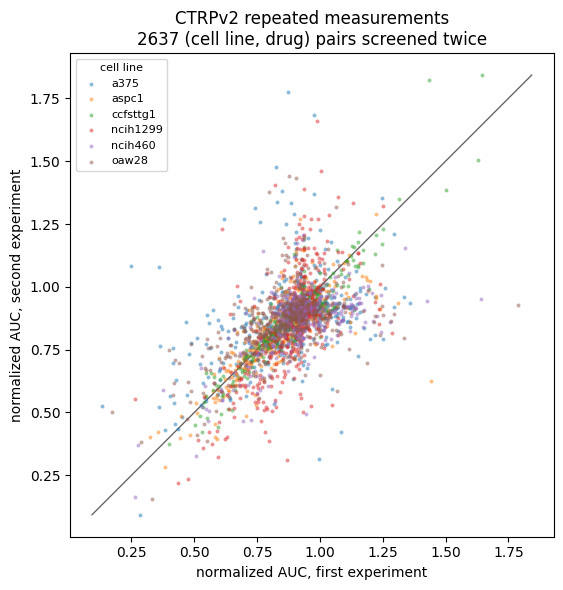

In [3]:
import matplotlib.pyplot as plt

OUT = ROOT / 'notebooks' / 'outputs' / 'data'

fig, ax = plt.subplots(figsize=(6, 6))
lo = min(pairs.rep1.min(), pairs.rep2.min())
hi = max(pairs.rep1.max(), pairs.rep2.max())
ax.plot([lo, hi], [lo, hi], color='0.4', lw=1, zorder=1)

for name, grp in pairs.groupby('ccl_name_norm'):
    ax.scatter(grp.rep1, grp.rep2, s=8, alpha=0.5, linewidths=0, label=name, zorder=2)

ax.set_xlabel('normalized AUC, first experiment')
ax.set_ylabel('normalized AUC, second experiment')
ax.set_title(f'CTRPv2 repeated measurements\n{len(pairs)} (cell line, drug) pairs screened twice')
ax.set_aspect('equal')
ax.legend(fontsize=8, loc='upper left', title='cell line', title_fontsize=8)
fig.tight_layout()
fig.savefig(OUT / 'replicate_variation.png', dpi=150)

pairs.to_csv(OUT / 'replicate_variation.csv', index=False)
print(f"wrote {OUT / 'replicate_variation.png'}")
print(f"wrote {OUT / 'replicate_variation.csv'}  ({len(pairs)} rows)")